In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Indexing simplices W_{3,e,w}(μ) by j-partitions via the e-abacus (r=3).

For fixed e and w:

- Partitions λ = (λ1 ≥ λ2 ≥ λ3 ≥ 0) are represented on the r=3 e-abacus
  by β-numbers: β_i = λ_i + (3-i), i=1,2,3.

- Each β gives:
      residue r = β mod e   (chooses a runner),
      quotient q = β // e   (vertical position on that runner).

- For a fixed λ:
    * The multiset of residues used (with multiplicity) records how the
      3 beads are distributed across runners → this is the composition μ of 3.
      E.g. (3), (2,1), (1,2), (1,1,1).

    * For each runner with μ_i beads, sorted q-values encode a partition
      λ^(i) with ℓ(λ^(i)) ≤ μ_i: move beads "down" to q=j baseline, and the
      differences q_j - j are the parts of λ^(i). Their total size is exactly
      the e-weight contribution of that runner.

- For fixed (e,w), each λ with e-weight=w and μ-pattern=μ determines a unique
  j-partition (λ^(1),...,λ^(j)). All λ with the same pair (μ, (λ^(1),...,λ^(j)))
  lie in one translated copy of the base simplex W_{3,e,0}(μ).

This file provides:
    - e_weight_of_partition
    - mu_composition
    - multipartition_index (μ and the j-partition label)
    - build_simplices_index: groups points by (μ, j-partition)
You can feed those groups into your existing plotting/alcove code.
"""

from collections import defaultdict
from typing import Dict, List, Tuple

# -----------------------------
# 1. Basic combinatorics (r=3)
# -----------------------------

def enumerate_partitions(Lmax: int):
    """
    Enumerate all 3-part partitions λ = (λ1 ≥ λ2 ≥ λ3 ≥ 0)
    with 0 ≤ λ1 ≤ Lmax.

    Lmax: a safe cutoff; choose large enough for your (e,w).
    """
    for l1 in range(Lmax + 1):
        for l2 in range(l1 + 1):
            for l3 in range(l2 + 1):
                yield (l1, l2, l3)


def beta_numbers(lam: Tuple[int, int, int]) -> List[int]:
    """
    r=3 β-numbers:
        β1 = λ1 + 2
        β2 = λ2 + 1
        β3 = λ3 + 0
    """
    l1, l2, l3 = lam
    return [l1 + 2, l2 + 1, l3]


def e_weight_of_partition(lam: Tuple[int, int, int], e: int) -> int:
    """
    Compute the e-weight w(λ) via the standard r-bead e-abacus recipe:

    1. For each β:
           residue r = β mod e
           quotient q = floor(β / e)
       → place a bead at position q on runner r.

    2. For each runner separately, sort the q's as:
           q_0 ≤ q_1 ≤ ... ≤ q_{μ-1}.
       On this runner's "e-core" configuration we would have beads at q=j.

       The number of upward moves is:
           sum_j (q_j - j).

    3. Sum this over all runners to get w(λ).

    This equals the usual notion of e-weight.
    """
    per_runner: Dict[int, List[int]] = defaultdict(list)
    for b in beta_numbers(lam):
        r = b % e
        q = b // e
        per_runner[r].append(q)

    w = 0
    for qs in per_runner.values():
        qs.sort()
        for j, q in enumerate(qs):
            w += (q - j)
    return w


# --------------------------------------
# 2. μ-composition (runner distribution)
# --------------------------------------

def mu_composition(lam: Tuple[int, int, int], e: int) -> Tuple[int, ...]:
    """
    μ-pattern for λ: record how many of the 3 beads lie on each used runner.

    More precisely:
      - collect residues r that occur in β mod e,
      - sort those runner indices increasingly,
      - on each such runner count how many beads it has,
      - return the tuple of those counts.

    Examples (for some λ):
      μ = (3)       -> all three β on one runner
      μ = (2,1)     -> two β on one runner, one on another
      μ = (1,2)     -> symmetrical
      μ = (1,1,1)   -> three distinct runners
    """
    counts: Dict[int, int] = defaultdict(int)
    for b in beta_numbers(lam):
        r = b % e
        counts[r] += 1
    return tuple(counts[r] for r in sorted(counts))


# -------------------------------------------------
# 3. j-partition index from the abacus (key part!)
# -------------------------------------------------

def multipartition_index(lam: Tuple[int, int, int], e: int):
    """
    Given λ, return:
        μ = μ-composition of 3,
        Λ = (λ^(1), ..., λ^(j)) the j-partition label for the simplex.

    Construction (all standard, just spelled out):

      - Compute β(λ).
      - Group by runner: for each residue r, get the quotients q.
      - Sort runners increasingly: r_1 < ... < r_j.
      - For runner r_i, let μ_i = number of beads; sort its q's:
            q_0 ≤ q_1 ≤ ... ≤ q_{μ_i-1}.
        The differences
            d_k = q_k - k   (k = 0..μ_i-1)
        are ≥ 0, and their multiset (in decreasing order) is a partition
        λ^(i) with length ≤ μ_i.

      - The total e-weight is:
            w(λ) = sum_i |λ^(i)|,
        and this decomposition is unique.

    Returns
    -------
    μ : tuple of ints, a composition of 3.
    multipart : tuple of partitions:
        each entry is a tuple of parts in *decreasing* order.
    """
    # Group β's by runner
    per_runner: Dict[int, List[int]] = defaultdict(list)
    for b in beta_numbers(lam):
        r = b % e
        q = b // e
        per_runner[r].append(q)

    # Order runners left-to-right by residue index
    runners = sorted(per_runner.keys())
    mu = tuple(len(per_runner[r]) for r in runners)

    multipart: List[Tuple[int, ...]] = []
    for r in runners:
        qs = sorted(per_runner[r])          # q_0 ≤ q_1 ≤ ...
        # "Excess over core": d_k = q_k - k
        diffs = [q - k for k, q in enumerate(qs)]
        # Form a partition: sort decreasing, drop zeros
        parts = sorted((d for d in diffs if d > 0), reverse=True)
        multipart.append(tuple(parts))

    return mu, tuple(multipart)


# ----------------------------------------
# 4. Dominant weight coordinates (ω1, ω2)
# ----------------------------------------

def omega_coords_lambda_plus_rho(lam: Tuple[int, int, int]) -> Tuple[int, int]:
    """
    Map λ+ρ to (ω1, ω2) for sl3:
        ω1 = λ1 - λ2 + 1
        ω2 = λ2 - λ3 + 1
    """
    l1, l2, l3 = lam
    return (l1 - l2 + 1, l2 - l3 + 1)


# -------------------------------------------------------------
# 5. Build the simplex index: (μ, j-partition) ↦ set of points
# -------------------------------------------------------------

def build_simplices_index(e: int, w_target: int, Lmax: int = 160):
    """
    For fixed (r,e,w)=(3,e,w_target), produce the decomposition:

        W_{3,e,w_target}
            = ⋃_{μ, Λ}  W_{3,e,w_target}(μ, Λ),

    where each piece W_{3,e,w}(μ,Λ) is one translated simplex, and
    Λ = (λ^(1),...,λ^(j)) is the j-partition label obtained from the abacus.

    Returns
    -------
    simplices : dict
        keys:  (μ, Λ) where
               μ is a composition of 3 (tuple of ints),
               Λ is a tuple of partitions (each partition is a tuple of ints).
        values: list of (ω1, ω2) lattice points (dominant weights)
                lying in that simplex.

    Usage
    -----
    - To get all points for a fixed μ:
          all_for_mu = []
          for (mu_key, multi), pts in simplices.items():
              if mu_key == μ:
                  all_for_mu.extend(pts)

    - To plot each simplex separately, use each (μ,Λ) bucket as one coloured
      or outlined simplex in your alcove picture.
    """
    simplices: Dict[Tuple[Tuple[int, ...], Tuple[Tuple[int, ...], ...]], List[Tuple[int, int]]] = defaultdict(list)

    for lam in enumerate_partitions(Lmax):
        if e_weight_of_partition(lam, e) != w_target:
            continue

        mu, multipart = multipartition_index(lam, e)
        omega = omega_coords_lambda_plus_rho(lam)

        key = (mu, multipart)
        simplices[key].append(omega)

    return simplices


# -----------------------------------------
# 6. Tiny demo / sanity check (optional)
# -----------------------------------------

if __name__ == "__main__":
    e = 8
    w = 2
    Lmax = 80

    simplices = build_simplices_index(e=e, w_target=w, Lmax=Lmax)

    # Print a brief summary: which (μ, Λ) occur, and how many points each has.
    print(f"(r,e,w) = (3,{e},{w})")
    print("Number of simplices (μ, j-partition):", len(simplices))
    for (mu, multipart), pts in sorted(simplices.items()):
        # multipart is ((λ^(1)), (λ^(2)), ...)
        label = " × ".join(
            ["(" + ",".join(map(str, lam_i)) + ")" if lam_i else "∅"
             for lam_i in multipart]
        )
        print(f"  μ={mu},  Λ={label:15s}  -> {len(pts)} points")


(r,e,w) = (3,8,2)
Number of simplices (μ, j-partition): 16
  μ=(1, 1, 1),  Λ=∅ × ∅ × (2)      -> 56 points
  μ=(1, 1, 1),  Λ=∅ × (1) × (1)    -> 56 points
  μ=(1, 1, 1),  Λ=∅ × (2) × ∅      -> 56 points
  μ=(1, 1, 1),  Λ=(1) × ∅ × (1)    -> 56 points
  μ=(1, 1, 1),  Λ=(1) × (1) × ∅    -> 56 points
  μ=(1, 1, 1),  Λ=(2) × ∅ × ∅      -> 56 points
  μ=(1, 2),  Λ=∅ × (1,1)        -> 28 points
  μ=(1, 2),  Λ=∅ × (2)          -> 28 points
  μ=(1, 2),  Λ=(1) × (1)        -> 28 points
  μ=(1, 2),  Λ=(2) × ∅          -> 28 points
  μ=(2, 1),  Λ=∅ × (2)          -> 28 points
  μ=(2, 1),  Λ=(1) × (1)        -> 28 points
  μ=(2, 1),  Λ=(1,1) × ∅        -> 28 points
  μ=(2, 1),  Λ=(2) × ∅          -> 28 points
  μ=(3,),  Λ=(1,1)            -> 8 points
  μ=(3,),  Λ=(2)              -> 8 points


Number of (μ, j-partition) simplices for (e,w)=(8,2): 16
  μ=(1, 1, 1), Λ=∅ × ∅ × (2)          -> 56 points
  μ=(1, 1, 1), Λ=∅ × (1) × (1)        -> 56 points
  μ=(1, 1, 1), Λ=∅ × (2) × ∅          -> 56 points
  μ=(1, 1, 1), Λ=(1) × ∅ × (1)        -> 56 points
  μ=(1, 1, 1), Λ=(1) × (1) × ∅        -> 56 points
  μ=(1, 1, 1), Λ=(2) × ∅ × ∅          -> 56 points
  μ=(1, 2), Λ=∅ × (1,1)            -> 28 points
  μ=(1, 2), Λ=∅ × (2)              -> 28 points
  μ=(1, 2), Λ=(1) × (1)            -> 28 points
  μ=(1, 2), Λ=(2) × ∅              -> 28 points
  μ=(2, 1), Λ=∅ × (2)              -> 28 points
  μ=(2, 1), Λ=(1) × (1)            -> 28 points
  μ=(2, 1), Λ=(1,1) × ∅            -> 28 points
  μ=(2, 1), Λ=(2) × ∅              -> 28 points
  μ=(3,), Λ=(1,1)                -> 8 points
  μ=(3,), Λ=(2)                  -> 8 points


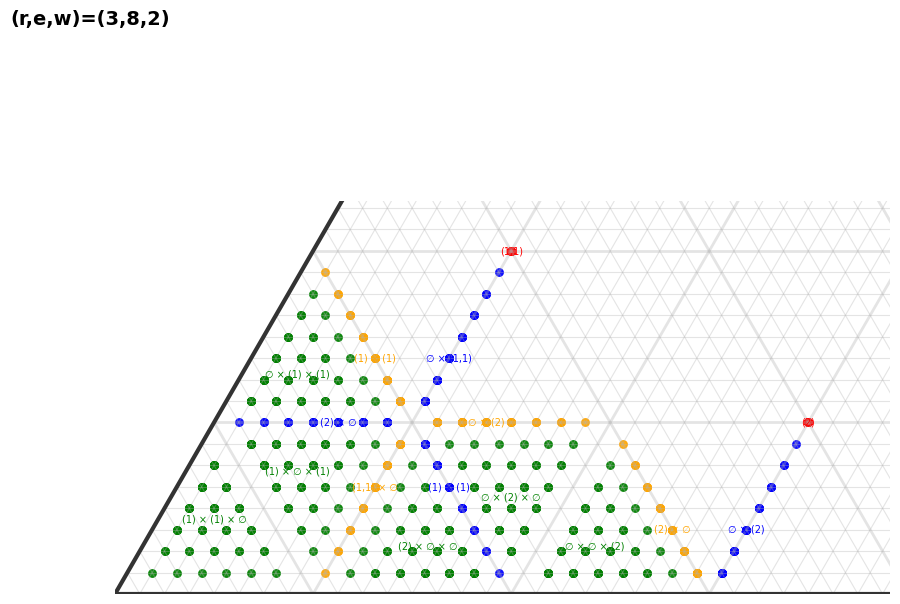

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
sl3_indexed_simplices.py

r = 3. For fixed (e, w), we:
  - enumerate partitions λ = (λ1 ≥ λ2 ≥ λ3 ≥ 0),
  - select those with given e-weight w,
  - compute:
        μ = μ-composition of 3 via the e-abacus (runner multiplicities),
        (λ^(1),...,λ^(j)) = j-partition from the vertical positions on each chosen runner,
  - group dominant weights (ω1, ω2) into buckets indexed by (μ, (λ^(1),...,λ^(j))).

Each bucket (μ, multipartition) is one translated simplex in W_{3,e,w}(μ),
i.e. a copy of W_{3,e,0}(μ). We draw:

  * Standard sl3 alcove view (equilateral A2):
        x = ω1 + 0.5 ω2,   y = (√3/2) ω2
  * A2 mesh with bold lines at multiples of e,
  * Little-ball points (colour determined by μ),
  * A label inside each simplex showing its j-partition index.

Adjust Lmax, font sizes, etc. as needed.
"""

import math
from collections import defaultdict
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, PathPatch
from matplotlib.path import Path

# -----------------------------
# 0. Global style & constants
# -----------------------------

SQRT3   = math.sqrt(3.0)
SQRT3_2 = SQRT3 / 2.0

# Colour by μ (composition of 3)
MU_COLOURS = {
    (3,):       "red",
    (2, 1):     "orange",
    (1, 2):     "blue",
    (1, 1, 1):  "green",
}
MU_ORDER = [(3,), (2, 1), (1, 2), (1, 1, 1)]


# ---------------------------------
# 1. Basic r=3 partition machinery
# ---------------------------------

def enumerate_partitions(Lmax: int):
    """
    Enumerate all 3-part partitions λ = (λ1 ≥ λ2 ≥ λ3 ≥ 0)
    with 0 ≤ λ1 ≤ Lmax.
    """
    for l1 in range(Lmax + 1):
        for l2 in range(l1 + 1):
            for l3 in range(l2 + 1):
                yield (l1, l2, l3)


def beta_numbers(lam: Tuple[int, int, int]) -> List[int]:
    """
    r=3 β-numbers:
        β1 = λ1 + 2
        β2 = λ2 + 1
        β3 = λ3 + 0
    """
    l1, l2, l3 = lam
    return [l1 + 2, l2 + 1, l3]


def e_weight_of_partition(lam: Tuple[int, int, int], e: int) -> int:
    """
    e-weight via abacus:

      - For each β:
            runner r = β mod e
            level  q = β // e
      - On each runner:
            sort q_0 ≤ ... ≤ q_{μ-1}
            contribute sum_j (q_j - j)
      - Sum over runners.
    """
    per_runner: Dict[int, List[int]] = defaultdict(list)
    for b in beta_numbers(lam):
        r = b % e
        q = b // e
        per_runner[r].append(q)

    w = 0
    for qs in per_runner.values():
        qs.sort()
        for j, q in enumerate(qs):
            w += (q - j)
    return w


def mu_composition(lam: Tuple[int, int, int], e: int) -> Tuple[int, ...]:
    """
    μ-composition of 3 from residues:
      μ records how many beads lie on each used runner,
      ordered by runner index.

    E.g. (3), (2,1), (1,2), (1,1,1).
    """
    counts: Dict[int, int] = defaultdict(int)
    for b in beta_numbers(lam):
        r = b % e
        counts[r] += 1
    return tuple(counts[r] for r in sorted(counts))


def multipartition_index(lam: Tuple[int, int, int], e: int):
    """
    From the abacus of λ, extract:

        μ = μ-composition (length j),
        Λ = (λ^(1), ..., λ^(j)):

      - For runner r_i with μ_i beads at q-values q_0 ≤ ... ≤ q_{μ_i-1},
        define d_k = q_k - k.
      - Positive d_k form parts of λ^(i).
      - Each λ^(i) has length ≤ μ_i, and
            w(λ) = sum_i |λ^(i)|.

    Returns (μ, Λ) with:
      μ: tuple of ints,
      Λ: tuple of partitions (each a tuple of ints in decreasing order).
    """
    per_runner: Dict[int, List[int]] = defaultdict(list)
    for b in beta_numbers(lam):
        r = b % e
        q = b // e
        per_runner[r].append(q)

    runners = sorted(per_runner.keys())
    mu = tuple(len(per_runner[r]) for r in runners)

    multipart: List[Tuple[int, ...]] = []
    for r in runners:
        qs = sorted(per_runner[r])
        diffs = [q - k for k, q in enumerate(qs)]
        parts = sorted((d for d in diffs if d > 0), reverse=True)
        multipart.append(tuple(parts))

    return mu, tuple(multipart)


def omega_coords_lambda_plus_rho(lam: Tuple[int, int, int]) -> Tuple[int, int]:
    """
    sl3: (λ+ρ) in fundamental weight coordinates:

        ω1 = λ1 - λ2 + 1
        ω2 = λ2 - λ3 + 1
    """
    l1, l2, l3 = lam
    return (l1 - l2 + 1, l2 - l3 + 1)


# -------------------------------------------------------------
# 2. Build simplices index: (μ, j-partition) -> {(ω1, ω2)}
# -------------------------------------------------------------

def build_simplices_index(e: int, w_target: int, Lmax: int = 160):
    """
    For fixed (e, w_target), r=3:

    Group all dominant weights (ω1, ω2) with e-weight = w_target
    by the pair (μ, Λ), where:

        μ = μ-composition of 3,
        Λ = (λ^(1),...,λ^(j)) from multipartition_index.

    Each key (μ, Λ) corresponds to one translated simplex
    in W_{3,e,w_target}(μ).

    Returns
    -------
    simplices : dict
        key:   (μ, Λ)
        value: list of (ω1, ω2) in that simplex.
    """
    simplices: Dict[
        Tuple[Tuple[int, ...], Tuple[Tuple[int, ...], ...]],
        List[Tuple[int, int]]
    ] = defaultdict(list)

    for lam in enumerate_partitions(Lmax):
        if e_weight_of_partition(lam, e) != w_target:
            continue

        mu, multipart = multipartition_index(lam, e)
        omega = omega_coords_lambda_plus_rho(lam)
        simplices[(mu, multipart)].append(omega)

    return simplices


# ---------------------------------
# 3. Equilateral sl3 plotting tools
# ---------------------------------

def to_equilateral(points_fw: List[Tuple[int, int]]):
    """
    Map (ω1, ω2) to standard A2 equilateral embedding:
        x = ω1 + 0.5 ω2,
        y = (√3/2) ω2.
    """
    X, Y = [], []
    for w1, w2 in points_fw:
        X.append(w1 + 0.5 * w2)
        Y.append(SQRT3_2 * w2)
    return X, Y


def extents_from_simplices(simplices) -> Tuple[float, float, float, float]:
    """
    Auto zoom box from all (ω1, ω2)-points (after equilateral embedding).
    """
    pts = [p for pts in simplices.values() for p in pts]
    if not pts:
        return (0.0, 1.0, 0.0, 1.0)
    X, Y = to_equilateral(pts)
    xmin, xmax = min(X), max(X)
    ymin, ymax = min(Y), max(Y)
    mx = max(2.0, 0.12 * (xmax - xmin + 1.0))
    my = max(2.0, 0.12 * (ymax - ymin + 1.0))
    xmin = max(0.0, xmin - mx)
    xmax = xmax + mx
    ymin = max(0.0, ymin - my)
    ymax = ymax + my
    return xmin, xmax, ymin, ymax


def draw_grid_equilateral(ax, xmin, xmax, ymin, ymax, e,
                          alpha=0.35, lw=0.8, lw_bold=2.0):
    """
    Draw A2 mesh in the equilateral embedding, with bold lines at multiples of e.
    """
    # ω2 = n  ->  y = (√3/2) n
    n2_max = int((2.0 / SQRT3) * (ymax + 1.0)) + 1
    for n in range(0, n2_max + 1):
        y = SQRT3_2 * n
        if y < ymin - 1 or y > ymax + 1:
            continue
        x0 = max(xmin, y / SQRT3)
        bold = (n % e == 0 and n != 0)
        ax.plot([x0, xmax], [y, y],
                color="0.7", alpha=alpha,
                linewidth=(lw_bold if bold else lw))

    # ω1 = n family
    n1_min = max(0, int(xmin) - 2)
    n1_max = int(xmax) + 2
    t_cap = int((2.0 / SQRT3) * (ymax + 1.0)) + 1
    for n in range(n1_min, n1_max + 1):
        x0, y0 = (n, 0.0)
        x1, y1 = (n + 0.5 * t_cap, SQRT3_2 * t_cap)
        bold = (n % e == 0 and n != 0)
        ax.plot([x0, x1], [y0, y1],
                color="0.7", alpha=alpha,
                linewidth=(lw_bold if bold else lw))

    # ω1 + ω2 = m family
    m_min = max(0, int(xmin)) - 2
    m_max = int(xmax + (2.0 / SQRT3) * (ymax + 1.0)) + 2
    for m in range(m_min, m_max + 1):
        x0, y0 = (m, 0.0)
        t_cap = min(max(0.0, (ymax + 1.0) * 2.0 / SQRT3), m)
        x1 = m - 0.5 * t_cap
        y1 = SQRT3_2 * t_cap
        bold = (m % e == 0 and m != 0)
        ax.plot([x0, x1], [y0, y1],
                color="0.7", alpha=alpha,
                linewidth=(lw_bold if bold else lw))


def wedge_clip_path_equilateral(xmin, xmax, ymin, ymax):
    """
    Clipping polygon for the dominant chamber in equilateral coordinates.
    """
    x0 = max(xmin, 0.0)
    x1 = min(xmax, ymax / SQRT3)
    verts = [
        (xmin, 0.0),
        (xmax, 0.0),
        (x1, SQRT3 * x1),
        (x0, SQRT3 * x0),
        (xmin, 0.0),
    ]
    codes = [Path.MOVETO] + [Path.LINETO] * 3 + [Path.CLOSEPOLY]
    return Path(verts, codes)


def draw_wedge_outline_equilateral(ax, xmin, xmax, ymin, ymax, lw=3.0):
    """
    Draw just the boundary of the dominant wedge:
      - base along y=0,
      - edge along y=√3 x.
    """
    ax.plot([xmin, xmax], [0.0, 0.0], color="0.2", linewidth=lw)
    x0 = max(xmin, 0.0)
    x1 = min(xmax, ymax / SQRT3)
    ax.plot([x0, x1], [SQRT3 * x0, SQRT3 * x1], color="0.2", linewidth=lw)


# ------------------------------------
# 4. Pretty label for the j-partition
# ------------------------------------

def multipartition_label(multipart: Tuple[Tuple[int, ...], ...]) -> str:
    """
    Turn Λ = (λ^(1),...,λ^(j)) into a concise text label.

    Example:
        ((2,1), (1,), ())  ->  "(2,1) × (1) × ∅"
    """
    factors = []
    for part in multipart:
        if not part:
            factors.append("∅")
        else:
            factors.append("(" + ",".join(str(x) for x in part) + ")")
    return " × ".join(factors)


# ------------------------------------------------
# 5. Main: draw indexed simplices in sl3 alcove
# ------------------------------------------------

def plot_sl3_indexed_simplices(
    e: int,
    w: int,
    Lmax: int = 160,
    figsize=(10, 8),
    label_fontsize: int = 8,
    max_labels: int = 200,
    out_prefix: str = None,
):
    """
    Draw the sl3 alcove picture for (r,e,w)=(3,e,w), with:

      - A2 equilateral mesh (bold multiples of e),
      - dominant wedge,
      - points coloured by μ,
      - each translated simplex W_{3,e,w}(μ,Λ) labeled by its j-partition Λ.

    Parameters
    ----------
    e, w : int
        Fixed modulus and e-weight.
    Lmax : int
        Partition size cutoff; increase if needed.
    figsize : (float,float)
        Figure size in inches.
    label_fontsize : int
        Font size for j-partition labels inside simplices.
    max_labels : int
        Safety cap to avoid over-crowding when there are many simplices.
    out_prefix : str or None
        If given, save as out_prefix + ".png" and ".pdf".

    Returns
    -------
    (fig, ax, simplices)
    """
    # 1) Build simplices index
    simplices = build_simplices_index(e=e, w_target=w, Lmax=Lmax)

    # 2) Setup figure
    xmin, xmax, ymin, ymax = extents_from_simplices(simplices)
    fig, ax = plt.subplots(figsize=figsize)

    draw_grid_equilateral(ax, xmin, xmax, ymin, ymax, e)
    clip = wedge_clip_path_equilateral(xmin, xmax, ymin, ymax)

    # Dot size schedule: larger for small w, smaller for big w
    sz = int(round(32 - 14 * min(max(w, 0), 10) / 10.0))
    sz = max(18, min(32, sz))

    # 3) Plot each simplex bucket
    labels_drawn = 0
    for (mu, multipart), pts_fw in simplices.items():
        if not pts_fw:
            continue

        color = MU_COLOURS.get(mu, "black")
        X, Y = to_equilateral(pts_fw)

        # Points (little balls)
        ax.scatter(X, Y, s=sz, marker="o", color=color, alpha=0.9)

        # Label this simplex by its j-partition near its barycenter
        if labels_drawn < max_labels:
            bx = sum(X) / len(X)
            by = sum(Y) / len(Y)
            label = multipartition_label(multipart)

            # Clip check: keep labels modestly inside wedge; no fancy adjustments.
            ax.text(
                bx,
                by,
                label,
                fontsize=label_fontsize,
                color=color,
                ha="center",
                va="center",
            )
            labels_drawn += 1

    # 4) Wedge outline & cosmetics
    draw_wedge_outline_equilateral(ax, xmin, xmax, ymin, ymax, lw=3.0)
    ax.set_aspect("equal", "box")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(max(0.0, ymin), ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Keep the (r,e,w) label OUTSIDE the fundamental chamber region
    fig.text(
        0.02,
        0.98,
        f"(r,e,w)=(3,{e},{w})",
        ha="left",
        va="top",
        fontsize=14,
        weight="bold",
    )

    # 5) Save if requested
    if out_prefix:
        png_path = f"{out_prefix}.png"
        pdf_path = f"{out_prefix}.pdf"
        fig.savefig(png_path, dpi=240, bbox_inches="tight")
        fig.savefig(pdf_path, dpi=240, bbox_inches="tight")
        return fig, ax, simplices

    return fig, ax, simplices


# -----------------------
# 6. Example usage
# -----------------------

if __name__ == "__main__":
    # Example: e = 8, w = 2 (pick w where you expect multiple translated simplices)
    fig, ax, simplices = plot_sl3_indexed_simplices(
        e=8,
        w=2,
        Lmax=120,
        figsize=(10, 8),
        label_fontsize=7,
        max_labels=200,
        out_prefix="sl3_e8_w2_indexed_simplices"
    )

    # Print a tiny summary to console
    print(f"Number of (μ, j-partition) simplices for (e,w)=(8,2): {len(simplices)}")
    for (mu, multipart), pts in sorted(simplices.items()):
        lbl = multipartition_label(multipart)
        print(f"  μ={mu}, Λ={lbl:20s} -> {len(pts)} points")


(r,e,w)=(3,10,5) has 50 (μ,Λ)-simplices.
  μ=(1, 1, 1), Λ=∅ × ∅ × (5)     -> 36 points
  μ=(1, 1, 1), Λ=∅ × (1) × (4)   -> 36 points
  μ=(1, 1, 1), Λ=∅ × (2) × (3)   -> 36 points
  μ=(1, 1, 1), Λ=∅ × (3) × (2)   -> 36 points
  μ=(1, 1, 1), Λ=∅ × (4) × (1)   -> 36 points
  μ=(1, 1, 1), Λ=∅ × (5) × ∅     -> 36 points
  μ=(1, 1, 1), Λ=(1) × ∅ × (4)   -> 36 points
  μ=(1, 1, 1), Λ=(1) × (1) × (3) -> 36 points
  μ=(1, 1, 1), Λ=(1) × (2) × (2) -> 36 points
  μ=(1, 1, 1), Λ=(1) × (3) × (1) -> 36 points
  μ=(1, 1, 1), Λ=(1) × (4) × ∅   -> 36 points
  μ=(1, 1, 1), Λ=(2) × ∅ × (3)   -> 36 points
  μ=(1, 1, 1), Λ=(2) × (1) × (2) -> 36 points
  μ=(1, 1, 1), Λ=(2) × (2) × (1) -> 36 points
  μ=(1, 1, 1), Λ=(2) × (3) × ∅   -> 36 points
  μ=(1, 1, 1), Λ=(3) × ∅ × (2)   -> 36 points
  μ=(1, 1, 1), Λ=(3) × (1) × (1) -> 36 points
  μ=(1, 1, 1), Λ=(3) × (2) × ∅   -> 36 points
  μ=(1, 1, 1), Λ=(4) × ∅ × (1)   -> 36 points
  μ=(1, 1, 1), Λ=(4) × (1) × ∅   -> 36 points
  μ=(1, 1, 1), Λ=(5) × ∅ × ∅     -> 36 

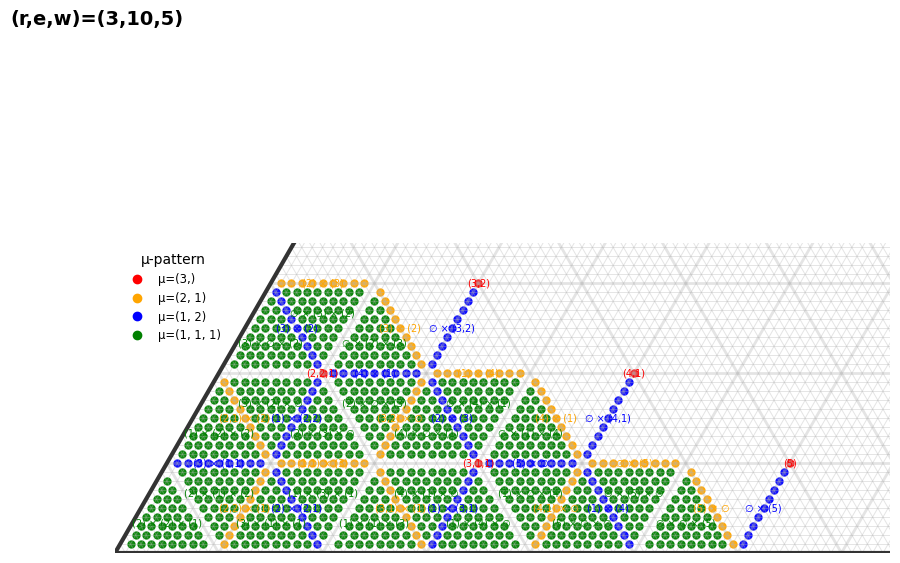

In [14]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
sl3_indexed_simplices_correct.py

r = 3. For fixed (e, w):

We realise W_{3,e,w} as a disjoint union of µ-simplices indexed by j-partitions:

  W_{3,e,w}(µ) = ⨆_{Λ} W_{3,e,w}(µ, Λ),

where
  µ is a composition of 3 (patterns of beads/runners),
  Λ = (λ^(1),...,λ^(j)) is a j-partition read off from the e-abacus,
  ℓ(λ^(i)) ≤ µ_i, sum_i |λ^(i)| = w.

This script:

  - Enumerates all λ = (λ1 ≥ λ2 ≥ λ3 ≥ 0) with a safe bound Lmax(e,w),
  - Keeps those with e-weight(λ) = w,
  - For each such λ:
        * Computes µ from residues of β-numbers,
        * Computes Λ from vertical gaps on each runner,
        * Computes its dominant weight (ω1, ω2),
  - Groups weights by (µ, Λ),
  - Deduplicates on (ω1,ω2),
  - Draws the standard sl3 alcove picture:
        * Equilateral embedding,
        * Grid with multiples of e bolded,
        * Dominant wedge,
        * Points as small balls, coloured by µ,
        * Each (µ,Λ) simplex labelled by Λ.

This matches the counting you expect, e.g. for (e,w)=(8,2):
  - 16 (µ,Λ)-simplices in total,
  - µ=(1,1,1): each Λ has 21 weights,
  - µ=(1,2),(2,1): each Λ has 7 weights,
  - µ=(3,): each Λ has 1 weight.
"""

import math
from collections import defaultdict
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch

# -----------------------------
# Global style & conventions
# -----------------------------

SQRT3   = math.sqrt(3.0)
SQRT3_2 = SQRT3 / 2.0

# Colours by µ-pattern:
MU_COLOURS = {
    (3,):       "red",
    (2, 1):     "orange",
    (1, 2):     "blue",
    (1, 1, 1):  "green",
}
MU_ORDER = [(3,), (2,1), (1,2), (1,1,1)]


# -----------------------------
# 1. Basic r=3 combinatorics
# -----------------------------

def enumerate_partitions(Lmax: int):
    """
    Enumerate 3-part partitions λ = (λ1 ≥ λ2 ≥ λ3 ≥ 0)
    with 0 ≤ λ1 ≤ Lmax.
    """
    for l1 in range(Lmax + 1):
        for l2 in range(l1 + 1):
            for l3 in range(l2 + 1):
                yield (l1, l2, l3)


def beta_numbers(lam: Tuple[int, int, int]) -> List[int]:
    """
    r=3 β-numbers:
        β1 = λ1 + 2,
        β2 = λ2 + 1,
        β3 = λ3 + 0.
    """
    l1, l2, l3 = lam
    return [l1 + 2, l2 + 1, l3]


def abacus_from_lam(lam: Tuple[int,int,int], e: int) -> Dict[int, List[int]]:
    """
    Place β(λ) on an e-runner abacus.

    Returns dict:
        runner r  -> sorted list of levels q,
    with β = r + e q.
    """
    per: Dict[int, List[int]] = defaultdict(list)
    for b in beta_numbers(lam):
        r = b % e
        q = b // e
        per[r].append(q)
    for r in per:
        per[r].sort()
    return per


def lam_from_betas(betas: List[int]) -> Tuple[int,int,int]:
    """
    Invert β ↦ λ for r=3.
    """
    bs = sorted(betas, reverse=True)
    assert len(bs) == 3
    l1 = bs[0] - 2
    l2 = bs[1] - 1
    l3 = bs[2] - 0
    assert l1 >= l2 >= l3 >= 0
    return (l1, l2, l3)


def lam_from_abacus(per: Dict[int,List[int]], e: int) -> Tuple[int,int,int]:
    """
    Collect β = r + e q from abacus and convert back to λ.
    """
    betas = []
    for r, qs in per.items():
        for q in qs:
            betas.append(r + e*q)
    return lam_from_betas(betas)


def e_weight(lam: Tuple[int,int,int], e: int) -> int:
    """
    e-weight via abacus:
      For each runner:
         let q_0 ≤ q_1 ≤ ... ≤ q_{μ-1},
         contrib = sum_j (q_j - j),
      sum over runners.

    This is the standard hook-length / abacus formula specialized to r=3.
    """
    per = abacus_from_lam(lam, e)
    w = 0
    for qs in per.values():
        qs = sorted(qs)
        for j, q in enumerate(qs):
            w += (q - j)
    return w


def mu_composition(lam: Tuple[int,int,int], e: int) -> Tuple[int, ...]:
    """
    μ-pattern from residues:
       - Count how many β lie on each runner,
       - Order runners increasingly,
       - Return the tuple of those counts.

    So μ is a composition of 3, e.g. (3), (2,1), (1,2), (1,1,1).
    """
    counts: Dict[int,int] = defaultdict(int)
    for b in beta_numbers(lam):
        counts[b % e] += 1
    runners = sorted(counts.keys())
    return tuple(counts[r] for r in runners)


def multipartition_index(lam: Tuple[int,int,int], e: int):
    """
    From the abacus of λ, extract (μ, Λ) as in your description.

    For each runner r used:
      - let μ_i = number of beads on that runner,
      - let q_0 ≤ ... ≤ q_{μ_i-1} be their levels,
      - define differences d_k = q_k - k ≥ 0,
      - the positive d_k form the parts of λ^(i) in decreasing order.

    Then:
      - μ = (μ_1,...,μ_j) is the composition of 3,
      - Λ = (λ^(1),...,λ^(j)) is the j-partition index.

    Returns
    -------
    μ : tuple of ints
    Λ : tuple of tuples (each inner tuple is a partition in decreasing order)
    """
    per = abacus_from_lam(lam, e)
    runners = sorted(per.keys())
    mu = tuple(len(per[r]) for r in runners)

    multipart = []
    for r in runners:
        qs = sorted(per[r])
        diffs = [q - j for j, q in enumerate(qs)]
        parts = sorted((d for d in diffs if d > 0), reverse=True)
        multipart.append(tuple(parts))

    return mu, tuple(multipart)


def omega_coords_lambda_plus_rho(lam: Tuple[int,int,int]) -> Tuple[int,int]:
    """
    Dominant weight in (ω1,ω2):

        ω1 = λ1 - λ2 + 1
        ω2 = λ2 - λ3 + 1
    """
    l1, l2, l3 = lam
    return (l1 - l2 + 1,  l2 - l3 + 1)


# -------------------------------------------
# 2. Safe Lmax bound depending on (e, w)
# -------------------------------------------

def safe_Lmax(e: int, w: int) -> int:
    """
    For r=3, e-weight w implies:

      For each runner, q_j - j ≥ 0 and sum(q_j - j) over all runners = w.
      Hence each q_j ≤ j + w.
      With at most 3 beads total, max q_j ≤ 2 + w.

      β = r + e q_j ≤ (e-1) + e(2+w) < e(w+3).
      So
          λ1 = max β - 2 < e(w+3).

    Thus Lmax = e*(w+3) is safe: all λ with e-weight = w and 3 parts lie below.
    """
    return e * (w + 3)


# --------------------------------------------------------
# 3. Build (µ, Λ)-indexed simplices of dominant weights
# --------------------------------------------------------

def build_mu_Lambda_buckets(e: int, w: int):
    """
    Enumerate all λ with e-weight(λ) = w (r=3), up to the safe bound Lmax(e,w),
    and group dominant weights (ω1,ω2) by their (μ, Λ) index.

    We *deduplicate* by (ω1,ω2) inside each bucket so that each weight in the
    alcove is counted once even if several λ give the same weight.

    Returns
    -------
    buckets : dict
        key:   (μ, Λ)
        value: set of (ω1,ω2)
    """
    Lmax = safe_Lmax(e, w)
    buckets: Dict[Tuple[Tuple[int,...], Tuple[Tuple[int,...],...]], set] = defaultdict(set)

    for lam in enumerate_partitions(Lmax):
        if e_weight(lam, e) != w:
            continue

        mu, multipart = multipartition_index(lam, e)
        omega = omega_coords_lambda_plus_rho(lam)
        buckets[(mu, multipart)].add(omega)

    return buckets


# ------------------------------------------------
# 4. Equilateral sl3 alcove plotting utilities
# ------------------------------------------------

def to_equilateral(points_fw: List[Tuple[int,int]]):
    """
    Map (ω1, ω2) to equilateral A2 coordinates:
        x = ω1 + 0.5 ω2
        y = (√3/2) ω2
    """
    X, Y = [], []
    for w1, w2 in points_fw:
        X.append(w1 + 0.5*w2)
        Y.append(SQRT3_2 * w2)
    return X, Y


def extents_from_buckets(buckets):
    """
    Choose a nice viewing window based on all points.
    """
    pts = [p for pts in buckets.values() for p in pts]
    if not pts:
        return (0,1,0,1)
    X, Y = to_equilateral(pts)
    xmin, xmax = min(X), max(X)
    ymin, ymax = min(Y), max(Y)
    mx = max(1.5, 0.15*(xmax - xmin + 1))
    my = max(1.5, 0.15*(ymax - ymin + 1))
    return max(0.0, xmin - mx), xmax + mx, max(0.0, ymin - my), ymax + my


def draw_grid_equilateral(ax, xmin, xmax, ymin, ymax, e,
                          alpha=0.35, lw=0.7, lw_bold=2.0):
    """
    sl3/A2 mesh with lines ω2 = const, ω1 = const, ω1+ω2 = const
    drawn in the equilateral embedding; lines at multiples of e bolded.
    """
    # ω2 = n  (horizontal in ω, slanted here)
    n2_max = int((2.0/SQRT3)*(ymax + 1)) + 1
    for n in range(0, n2_max + 1):
        y = SQRT3_2 * n
        if y < ymin - 1 or y > ymax + 1:
            continue
        x0 = max(xmin, y / SQRT3)
        bold = (n % e == 0 and n != 0)
        ax.plot([x0, xmax], [y, y],
                color="0.7", alpha=alpha,
                linewidth=(lw_bold if bold else lw))

    # ω1 = n family
    n1_min = max(0, int(xmin) - 2)
    n1_max = int(xmax) + 2
    t_cap  = int((2.0/SQRT3)*(ymax + 1)) + 1
    for n in range(n1_min, n1_max + 1):
        x0, y0 = (n, 0.0)
        x1, y1 = (n + 0.5*t_cap, SQRT3_2*t_cap)
        bold = (n % e == 0 and n != 0)
        ax.plot([x0, x1], [y0, y1],
                color="0.7", alpha=alpha,
                linewidth=(lw_bold if bold else lw))

    # ω1 + ω2 = m family
    m_min = max(0, int(xmin)) - 2
    m_max = int(xmax + (2.0/SQRT3)*(ymax + 1)) + 2
    for m in range(m_min, m_max + 1):
        x0, y0 = (m, 0.0)
        t_cap = min(max(0.0, (ymax + 1)*2.0/SQRT3), m)
        x1 = m - 0.5*t_cap
        y1 = SQRT3_2 * t_cap
        bold = (m % e == 0 and m != 0)
        ax.plot([x0, x1], [y0, y1],
                color="0.7", alpha=alpha,
                linewidth=(lw_bold if bold else lw))


def wedge_clip_equilateral(xmin, xmax, ymin, ymax):
    """
    Dominant chamber wedge clip in equilateral coords:
      bounded by y=0 and y=√3 x.
    """
    x0 = max(xmin, 0.0)
    x1 = min(xmax, ymax / SQRT3)
    verts = [
        (xmin, 0.0),
        (xmax, 0.0),
        (x1, SQRT3*x1),
        (x0, SQRT3*x0),
        (xmin, 0.0),
    ]
    codes = [Path.MOVETO] + [Path.LINETO]*3 + [Path.CLOSEPOLY]
    return Path(verts, codes)


def draw_wedge_outline_equilateral(ax, xmin, xmax, ymin, ymax, lw=3.0):
    """
    Draw boundary of the dominant wedge.
    """
    ax.plot([xmin, xmax], [0.0, 0.0], color="0.2", linewidth=lw)
    x0 = max(xmin, 0.0)
    x1 = min(xmax, ymax / SQRT3)
    ax.plot([x0, x1], [SQRT3*x0, SQRT3*x1], color="0.2", linewidth=lw)


def multipartition_label(multipart: Tuple[Tuple[int,...], ...]) -> str:
    """
    Pretty label for Λ = (λ^(1),...,λ^(j)).

    Example:
        ( (2,1), (1,), () )  -> "(2,1) × (1) × ∅"
    """
    pieces = []
    for lam in multipart:
        if not lam:
            pieces.append("∅")
        else:
            pieces.append("(" + ",".join(str(x) for x in lam) + ")")
    return " × ".join(pieces)


# ------------------------------------------------
# 5. Main: draw indexed simplices for (e,w)
# ------------------------------------------------

def plot_sl3_indexed_simplices(e: int, w: int,
                               label_fontsize: int = 7,
                               max_labels: int = 999,
                               out_prefix: str = None):
    """
    Draw the sl3 alcove picture for (r,e,w)=(3,e,w), with:

      - A2 equilateral mesh (multiples of e bold),
      - dominant wedge,
      - points as small balls,
      - colour of a point determined by μ,
      - each (μ,Λ)-simplex labelled by its j-partition Λ (barycentre),
      - a colour legend for μ in the UPPER LEFT, outside the chamber.
    """
    buckets = build_mu_Lambda_buckets(e, w)

    all_points = [p for pts in buckets.values() for p in pts]
    if not all_points:
        raise RuntimeError(f"No points for (e,w)=({e},{w}).")

    xmin, xmax, ymin, ymax = extents_from_buckets(buckets)
    fig, ax = plt.subplots(figsize=(10, 8))

    draw_grid_equilateral(ax, xmin, xmax, ymin, ymax, e)
    clip = wedge_clip_equilateral(xmin, xmax, ymin, ymax)

    # point size schedule
    sz = int(round(32 - 14 * min(max(w, 0), 10) / 10.0))
    sz = max(18, min(32, sz))

    labels_drawn = 0

    # plot simplices
    for (mu, multipart), pts_fw in sorted(buckets.items()):
        if not pts_fw:
            continue

        color = MU_COLOURS.get(mu, "black")
        X, Y = to_equilateral(sorted(pts_fw))

        ax.scatter(X, Y, s=sz, marker="o", color=color, alpha=0.9)

        if labels_drawn < max_labels:
            bx = sum(X) / len(X)
            by = sum(Y) / len(Y)
            ax.text(
                bx,
                by,
                multipartition_label(multipart),
                fontsize=label_fontsize,
                color=color,
                ha="center",
                va="center",
            )
            labels_drawn += 1

    # wedge outline & cosmetics
    draw_wedge_outline_equilateral(ax, xmin, xmax, ymin, ymax, lw=3.0)
    ax.set_aspect("equal", "box")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(max(0.0, ymin), ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # (r,e,w) label OUTSIDE chamber
    fig.text(
        0.02,
        0.98,
        f"(r,e,w)=(3,{e},{w})",
        ha="left",
        va="top",
        fontsize=14,
        weight="bold",
    )

    # ---------- NEW: μ-colour legend in upper left ----------
    from matplotlib.lines import Line2D

    legend_elements = []
    for mu in MU_ORDER:
        if any(key_mu == mu for (key_mu, _Λ) in buckets.keys()):
            legend_elements.append(
                Line2D(
                    [0], [0],
                    marker="o",
                    linestyle="",
                    markersize=6,
                    color=MU_COLOURS[mu],
                    label=f"μ={mu}",
                )
            )

    if legend_elements:
        # place legend in upper-left corner of axes, inside padding
        # but visually away from the main chamber
        ax.legend(
            handles=legend_elements,
            title="μ-pattern",
            loc="upper left",
            frameon=False,
            fontsize="small",
        )

    # save if requested
    if out_prefix:
        fig.savefig(f"{out_prefix}.png", dpi=240, bbox_inches="tight")
        fig.savefig(f"{out_prefix}.pdf", dpi=240, bbox_inches="tight")

    return fig, ax, buckets



# ------------------------------------------------
# 6. Example sanity check
# ------------------------------------------------

if __name__ == "__main__":
    # Example: (e,w) = (8,2), the case you checked
    e, w = 10, 5
    fig, ax, buckets = plot_sl3_indexed_simplices(
        e=e,
        w=w,
        label_fontsize=7,
        out_prefix=f"sl3_e{e}_w{w}_indexed"
    )

    print(f"(r,e,w)=(3,{e},{w}) has {len(buckets)} (μ,Λ)-simplices.")
    for (mu, Λ), pts in sorted(buckets.items()):
        print(f"  μ={mu}, Λ={multipartition_label(Λ):15s} -> {len(pts)} points")


(r,e,w)=(3,10,5) has 50 (μ,Λ)-simplices.
  μ=(1, 1, 1), Λ=∅·∅·(5)         -> 36 points
  μ=(1, 1, 1), Λ=∅·(1)·(4)       -> 36 points
  μ=(1, 1, 1), Λ=∅·(2)·(3)       -> 36 points
  μ=(1, 1, 1), Λ=∅·(3)·(2)       -> 36 points
  μ=(1, 1, 1), Λ=∅·(4)·(1)       -> 36 points
  μ=(1, 1, 1), Λ=∅·(5)·∅         -> 36 points
  μ=(1, 1, 1), Λ=(1)·∅·(4)       -> 36 points
  μ=(1, 1, 1), Λ=(1)·(1)·(3)     -> 36 points
  μ=(1, 1, 1), Λ=(1)·(2)·(2)     -> 36 points
  μ=(1, 1, 1), Λ=(1)·(3)·(1)     -> 36 points
  μ=(1, 1, 1), Λ=(1)·(4)·∅       -> 36 points
  μ=(1, 1, 1), Λ=(2)·∅·(3)       -> 36 points
  μ=(1, 1, 1), Λ=(2)·(1)·(2)     -> 36 points
  μ=(1, 1, 1), Λ=(2)·(2)·(1)     -> 36 points
  μ=(1, 1, 1), Λ=(2)·(3)·∅       -> 36 points
  μ=(1, 1, 1), Λ=(3)·∅·(2)       -> 36 points
  μ=(1, 1, 1), Λ=(3)·(1)·(1)     -> 36 points
  μ=(1, 1, 1), Λ=(3)·(2)·∅       -> 36 points
  μ=(1, 1, 1), Λ=(4)·∅·(1)       -> 36 points
  μ=(1, 1, 1), Λ=(4)·(1)·∅       -> 36 points
  μ=(1, 1, 1), Λ=(5)·∅·∅         -> 36 

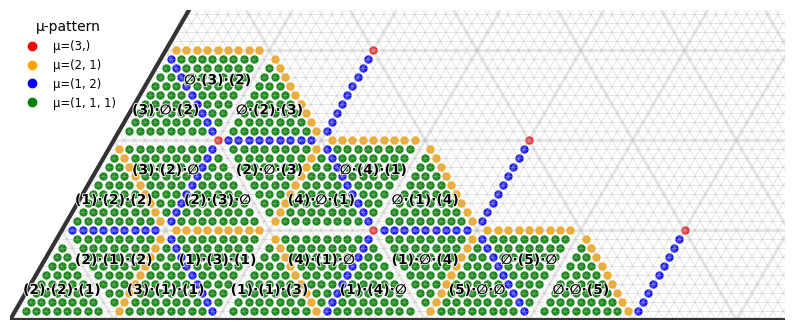

In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
sl3_mu_indexed_plot.py

r = 3. For fixed (e, w):

- Enumerate partitions λ = (λ1 ≥ λ2 ≥ λ3 ≥ 0).
- Keep those with e-weight(λ) = w (via abacus).
- For each λ:
    * Compute μ = composition of 3 from residues (β mod e).
    * Compute Λ = (λ^(1),...,λ^(j)) from vertical gaps (q_j - j) on each runner.
    * Compute dominant weight (ω1,ω2) of λ+ρ.
- Group weights by (μ, Λ).

We then draw the standard sl3 alcove picture in the equilateral model with:
    - A2 mesh; lines at multiples of e bold.
    - Dominant chamber wedge.
    - Points as little balls; colour = μ.
    - j-partition labels at barycentres.

Control:
    - label_mu=None   -> label all μ in their color.
    - label_mu=(3,)   -> label only μ=(3) simplices, labels in BLACK.
    - label_mu=(2,1), (1,2), (1,1,1) similarly.

Also provides interactive_mu_picker(e,w) for Jupyter to switch μ.
"""

import math
from collections import defaultdict
from typing import Dict, List, Tuple, Set, Optional

import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch

# -----------------------------
# Global style & palette
# -----------------------------

SQRT3 = math.sqrt(3.0)
SQRT3_2 = SQRT3 / 2.0

# μ-colours:
#   (3)       -> red
#   (2,1)     -> orange
#   (1,2)     -> blue
#   (1,1,1)   -> green
MU_COLOURS: Dict[Tuple[int, ...], str] = {
    (3,): "red",
    (2, 1): "orange",
    (1, 2): "blue",
    (1, 1, 1): "green",
}
MU_ORDER = [(3,), (2, 1), (1, 2), (1, 1, 1)]


# -----------------------------
# 1. r=3 combinatorics & abacus
# -----------------------------

def enumerate_partitions(Lmax: int):
    """
    Enumerate 3-part partitions λ = (λ1 ≥ λ2 ≥ λ3 ≥ 0) with 0 ≤ λ1 ≤ Lmax.
    """
    for l1 in range(Lmax + 1):
        for l2 in range(l1 + 1):
            for l3 in range(l2 + 1):
                yield (l1, l2, l3)


def beta_numbers(lam: Tuple[int, int, int]) -> List[int]:
    """
    r=3 β-numbers:
        β1 = λ1 + 2,
        β2 = λ2 + 1,
        β3 = λ3 + 0.
    """
    l1, l2, l3 = lam
    return [l1 + 2, l2 + 1, l3]


def abacus_from_lam(lam: Tuple[int, int, int], e: int) -> Dict[int, List[int]]:
    """
    Build e-runner abacus from λ:
      β = r + e q  -> bead at level q on runner r.
    Returns dict r -> sorted list of q.
    """
    per: Dict[int, List[int]] = defaultdict(list)
    for b in beta_numbers(lam):
        r = b % e
        q = b // e
        per[r].append(q)
    for r in per:
        per[r].sort()
    return per


def lam_from_betas(betas: List[int]) -> Tuple[int, int, int]:
    """
    Invert β ↦ λ for r=3.
    """
    bs = sorted(betas, reverse=True)
    assert len(bs) == 3
    l1 = bs[0] - 2
    l2 = bs[1] - 1
    l3 = bs[2] - 0
    assert l1 >= l2 >= l3 >= 0
    return (l1, l2, l3)


def lam_from_abacus(per: Dict[int, List[int]], e: int) -> Tuple[int, int, int]:
    """
    Collect β = r + e q from abacus and convert to λ.
    """
    betas: List[int] = []
    for r, qs in per.items():
        for q in qs:
            betas.append(r + e * q)
    return lam_from_betas(betas)


def e_weight(lam: Tuple[int, int, int], e: int) -> int:
    """
    e-weight via abacus:
      For each runner:
         q_0 ≤ ... ≤ q_{μ-1},
         contrib = sum_j (q_j - j),
      sum over runners.
    """
    per = abacus_from_lam(lam, e)
    w = 0
    for qs in per.values():
        for j, q in enumerate(sorted(qs)):
            w += (q - j)
    return w


def mu_composition(lam: Tuple[int, int, int], e: int) -> Tuple[int, ...]:
    """
    μ-composition from residues:
      - count β on each runner,
      - order runners increasingly,
      - return counts.
    """
    counts: Dict[int, int] = defaultdict(int)
    for b in beta_numbers(lam):
        counts[b % e] += 1
    runners = sorted(counts.keys())
    return tuple(counts[r] for r in runners)


def multipartition_index(lam: Tuple[int, int, int], e: int):
    """
    From abacus of λ, extract (μ, Λ) as in your definition.

    For each runner r used:
        μ_i = #beads,
        q_0 ≤ ... ≤ q_{μ_i-1},
        d_k = q_k - k ≥ 0,
        positive d_k in decreasing order form λ^(i).

    Returns
    -------
    μ : tuple of ints (composition of 3)
    Λ : tuple of partitions, each a tuple of ints in decreasing order.
    """
    per = abacus_from_lam(lam, e)
    runners = sorted(per.keys())
    mu = tuple(len(per[r]) for r in runners)

    multipart: List[Tuple[int, ...]] = []
    for r in runners:
        qs = sorted(per[r])
        diffs = [q - j for j, q in enumerate(qs)]
        parts = sorted((d for d in diffs if d > 0), reverse=True)
        multipart.append(tuple(parts))

    return mu, tuple(multipart)


def omega_coords_lambda_plus_rho(lam: Tuple[int, int, int]) -> Tuple[int, int]:
    """
    Dominant weight (λ+ρ) in (ω1,ω2):
        ω1 = λ1 - λ2 + 1
        ω2 = λ2 - λ3 + 1
    """
    l1, l2, l3 = lam
    return (l1 - l2 + 1, l2 - l3 + 1)


# -----------------------------
# 2. Lmax depending on (e,w)
# -----------------------------

def safe_Lmax(e: int, w: int) -> int:
    """
    Safe bound for λ1 for r=3, given e-weight w.

    Sketch:
      On each runner, q_j - j ≥ 0 and sum(q_j - j) = w.
      So q_j ≤ j + w. With at most 3 beads, max q_j ≤ 2 + w.
      β_max ≤ (e-1) + e(2 + w) < e(w+3).
      λ1 = β_max - 2 < e(w+3).

    So Lmax = e*(w+3) is safe.
    """
    return e * (w + 3)


# -----------------------------
# 3. Build (μ,Λ) buckets
# -----------------------------

def build_mu_Lambda_buckets(e: int, w: int):
    """
    Enumerate all λ with e-weight(λ)=w up to Lmax(e,w),
    group dominant weights by (μ, Λ).

    Returns
    -------
    buckets : dict
        (μ, Λ) -> set of (ω1,ω2)
    """
    Lmax = safe_Lmax(e, w)
    buckets: Dict[Tuple[Tuple[int, ...], Tuple[Tuple[int, ...], ...]], Set[Tuple[int, int]]] = defaultdict(set)

    for lam in enumerate_partitions(Lmax):
        if e_weight(lam, e) != w:
            continue

        mu, multipart = multipartition_index(lam, e)
        omega = omega_coords_lambda_plus_rho(lam)
        buckets[(mu, multipart)].add(omega)

    return buckets


# -----------------------------
# 4. Equilateral sl3 geometry
# -----------------------------

def to_equilateral(points_fw: List[Tuple[int, int]]):
    """
    (ω1,ω2) -> (x,y) for equilateral A2 embedding:
        x = ω1 + 0.5 ω2
        y = (√3/2) ω2
    """
    X, Y = [], []
    for w1, w2 in points_fw:
        X.append(w1 + 0.5 * w2)
        Y.append(SQRT3_2 * w2)
    return X, Y


def extents_from_buckets(buckets) -> Tuple[float, float, float, float]:
    """
    Choose viewing window from all weights.
    """
    pts = [p for pts in buckets.values() for p in pts]
    if not pts:
        return (0.0, 1.0, 0.0, 1.0)
    X, Y = to_equilateral(pts)
    xmin, xmax = min(X), max(X)
    ymin, ymax = min(Y), max(Y)
    mx = max(1.5, 0.15 * (xmax - xmin + 1.0))
    my = max(1.5, 0.15 * (ymax - ymin + 1.0))
    return max(0.0, xmin - mx), xmax + mx, max(0.0, ymin - my), ymax + my


def draw_grid_equilateral(ax, xmin, xmax, ymin, ymax, e: int,
                          alpha: float = 0.35,
                          lw: float = 0.7,
                          lw_bold: float = 2.0):
    """
    Draw A2 mesh:
      - families: ω2 = const, ω1 = const, ω1+ω2 = const
      - multiples of e bold.
    """

    # ω2 = n
    n2_max = int((2.0 / SQRT3) * (ymax + 1.0)) + 1
    for n in range(0, n2_max + 1):
        y = SQRT3_2 * n
        if y < ymin - 1 or y > ymax + 1:
            continue
        x0 = max(xmin, y / SQRT3)
        bold = (n % e == 0 and n != 0)
        ax.plot([x0, xmax], [y, y],
                color="0.7", alpha=alpha,
                linewidth=(lw_bold if bold else lw))

    # ω1 = n
    n1_min = max(0, int(xmin) - 2)
    n1_max = int(xmax) + 2
    t_cap = int((2.0 / SQRT3) * (ymax + 1.0)) + 1
    for n in range(n1_min, n1_max + 1):
        x0, y0 = (n, 0.0)
        x1, y1 = (n + 0.5 * t_cap, SQRT3_2 * t_cap)
        bold = (n % e == 0 and n != 0)
        ax.plot([x0, x1], [y0, y1],
                color="0.7", alpha=alpha,
                linewidth=(lw_bold if bold else lw))

    # ω1 + ω2 = m
    m_min = max(0, int(xmin)) - 2
    m_max = int(xmax + (2.0 / SQRT3) * (ymax + 1.0)) + 2
    for m in range(m_min, m_max + 1):
        x0, y0 = (m, 0.0)
        t_cap = min(max(0.0, (ymax + 1.0) * 2.0 / SQRT3), m)
        x1 = m - 0.5 * t_cap
        y1 = SQRT3_2 * t_cap
        bold = (m % e == 0 and m != 0)
        ax.plot([x0, x1], [y0, y1],
                color="0.7", alpha=alpha,
                linewidth=(lw_bold if bold else lw))


def wedge_clip_equilateral(xmin, xmax, ymin, ymax):
    """
    Dominant chamber wedge as clipping path.
    """
    x0 = max(xmin, 0.0)
    x1 = min(xmax, ymax / SQRT3)
    verts = [
        (xmin, 0.0),
        (xmax, 0.0),
        (x1, SQRT3 * x1),
        (x0, SQRT3 * x0),
        (xmin, 0.0),
    ]
    codes = [Path.MOVETO] + [Path.LINETO] * 3 + [Path.CLOSEPOLY]
    return Path(verts, codes)


def draw_wedge_outline_equilateral(ax, xmin, xmax, ymin, ymax, lw: float = 3.0):
    """
    Draw boundary of dominant wedge (y=0 and y=√3 x).
    """
    ax.plot([xmin, xmax], [0.0, 0.0], color="0.2", linewidth=lw)
    x0 = max(xmin, 0.0)
    x1 = min(xmax, ymax / SQRT3)
    ax.plot([x0, x1], [SQRT3 * x0, SQRT3 * x1], color="0.2", linewidth=lw)


def multipartition_label(multipart: Tuple[Tuple[int, ...], ...]) -> str:
    """
    Compact label for Λ = (λ^(1),...,λ^(j)).

    Old style: "(2,1) × (1) × ∅"
    New compact style: "(2,1)·(1)·∅"

    Uses middle dot with no surrounding spaces to save horizontal room.
    """
    pieces: List[str] = []
    for lam in multipart:
        if not lam:
            pieces.append("∅")
        else:
            pieces.append("(" + ",".join(str(x) for x in lam) + ")")
    return "·".join(pieces)



# -----------------------------
# 5. Main plotting function
# -----------------------------

import math
from collections import defaultdict
from typing import Dict, List, Tuple, Set, Optional

import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import matplotlib.patheffects as patheffects  # <-- make sure this is here

# ... keep your other helpers: enumerate_partitions, e_weight, build_mu_Lambda_buckets,
# to_equilateral, extents_from_buckets, draw_grid_equilateral,
# wedge_clip_equilateral, draw_wedge_outline_equilateral,
# multipartition_label, MU_COLOURS, MU_ORDER, etc.

def plot_sl3_indexed_simplices(
    e: int,
    w: int,
    label_mu: Optional[Tuple[int, ...]] = None,
    label_fontsize: int = 7,
    max_labels: int = 999,
    out_prefix: Optional[str] = None,
):
    """
    Draw the sl3 alcove picture for (r,e,w) = (3,e,w).

    - All points are drawn as coloured balls (colour determined by μ).
    - If label_mu is None:
          Label every (μ,Λ)-simplex in its μ-colour.
    - If label_mu is one of (3,), (2,1), (1,2), (1,1,1):
          Only simplices with that μ are labelled,
          and those labels are bold BLACK with a thin white halo
          to be clear over dense dots.
    """
    buckets = build_mu_Lambda_buckets(e, w)  # (μ,Λ) -> set of (ω1,ω2)

    all_points = [p for pts in buckets.values() for p in pts]
    if not all_points:
        raise RuntimeError(f"No points for (e,w)=({e},{w}).")

    xmin, xmax, ymin, ymax = extents_from_buckets(buckets)

    fig, ax = plt.subplots(figsize=(10, 8))

    draw_grid_equilateral(ax, xmin, xmax, ymin, ymax, e)
    clip = wedge_clip_equilateral(xmin, xmax, ymin, ymax)

    # Point size: shrink mildly with w
    sz = int(round(32 - 14 * min(max(w, 0), 10) / 10.0))
    sz = max(18, min(32, sz))

    labels_drawn = 0

    for (mu, multipart), pts_fw in sorted(buckets.items()):
        if not pts_fw:
            continue

        color = MU_COLOURS.get(mu, "black")
        X, Y = to_equilateral(sorted(pts_fw))

        # Draw all points in μ-colour
        ax.scatter(X, Y, s=sz, marker="o", color=color, alpha=0.9)

        # Decide if this simplex should be labelled
        if label_mu is None:
            # Label all simplices, in their μ-colour
            do_label = True
            label_color = color
            bold = False
            halo = False
        else:
            # Only label simplices whose μ matches label_mu
            if mu == label_mu:
                do_label = True
                label_color = "black"
                bold = True
                halo = True
            else:
                do_label = False
                label_color = color
                bold = False
                halo = False

        if do_label and labels_drawn < max_labels:
            bx = sum(X) / len(X)
            by = sum(Y) / len(Y)
            text = multipartition_label(multipart)

            txt = ax.text(
                bx,
                by,
                text,
                fontsize=label_fontsize,
                color=label_color,
                ha="center",
                va="center",
                fontweight="bold" if bold else "normal",
            )

            if halo:
                # thin white outline around black text for clarity
                txt.set_path_effects([
                    patheffects.Stroke(linewidth=1.2, foreground="white"),
                    patheffects.Normal(),
                ])

            labels_drawn += 1

    # Draw wedge outline
    draw_wedge_outline_equilateral(ax, xmin, xmax, ymin, ymax, lw=3.0)

    # Cosmetics
    ax.set_aspect("equal", "box")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(max(0.0, ymin), ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # (r,e,w) label outside the chamber
    # fig.text(
    #     0.02,
    #     0.98,
    #     f"(r,e,w)=(3,{e},{w})",
    #     ha="left",
    #     va="top",
    #     fontsize=14,
    #     weight="bold",
    # )

    # μ-colour legend in upper left
    from matplotlib.lines import Line2D
    legend_elements: List[Line2D] = []
    for mu in MU_ORDER:
        if any(key_mu == mu for (key_mu, _Λ) in buckets.keys()):
            legend_elements.append(
                Line2D(
                    [0], [0],
                    marker="o",
                    linestyle="",
                    markersize=6,
                    color=MU_COLOURS[mu],
                    label=f"μ={mu}",
                )
            )
    if legend_elements:
        ax.legend(
            handles=legend_elements,
            title="μ-pattern",
            loc="upper left",
            frameon=False,
            fontsize="small",
        )

    if out_prefix:
        fig.savefig(f"{out_prefix}.png", dpi=240, bbox_inches="tight")
        # fig.savefig(f"{out_prefix}.pdf", dpi=240, bbox_inches="tight")

    return fig, ax, buckets



# -----------------------------
# 6. Jupyter "button" interface
# -----------------------------

def interactive_mu_picker(
    e: int,
    w: int,
    label_fontsize: int = 7,
    max_labels: int = 999,
):
    """
    Jupyter helper:

      - Shows toggle buttons for μ ∈ {(3), (2,1), (1,2), (1,1,1)}.
      - Redraws the (e,w) picture each time.
      - Points always coloured by μ.
      - Only chosen μ has Λ-labels, in black.

    Usage in a notebook:
        from sl3_mu_indexed_plot import interactive_mu_picker
        interactive_mu_picker(e=10, w=12)
    """
    try:
        from ipywidgets import ToggleButtons, VBox, Output
        from IPython.display import display
        import matplotlib.pyplot as plt
    except ImportError:
        print("ipywidgets/IPython not available; use plot_sl3_indexed_simplices(...) directly.")
        return

    mu_options = {
        "μ=(3,)": (3,),
        "μ=(2,1)": (2, 1),
        "μ=(1,2)": (1, 2),
        "μ=(1,1,1)": (1, 1, 1),
    }

    out = Output()

    def redraw(mu_label: str):
        mu = mu_options[mu_label]
        with out:
            out.clear_output(wait=True)
            fig, ax, _ = plot_sl3_indexed_simplices(
                e=e,
                w=w,
                label_mu=mu,
                label_fontsize=label_fontsize,
                max_labels=max_labels,
                out_prefix=None,
            )
            plt.show()

    buttons = ToggleButtons(
        options=list(mu_options.keys()),
        description="Choose μ:",
        disabled=False,
        button_style="",
    )

    def on_change(change):
        if change["name"] == "value" and change["new"] is not None:
            redraw(change["new"])

    buttons.observe(on_change, names="value")

    display(VBox([buttons, out]))

    # initial draw
    buttons.value = "μ=(3,)"


# -----------------------------
# 7. Example direct run
# -----------------------------

if __name__ == "__main__":
    # Example: (e,w) = (8,2), label only μ=(1,1,1) simplices in black
    e, w = 10,5
    fig, ax, buckets = plot_sl3_indexed_simplices(
        e=e,
        w=w,
        label_mu=(1,1,1),          # choose which μ to display labels for
        label_fontsize=10,
        max_labels=999,
        out_prefix=f"sl3_e{e}_w{w}_mu111"
    )

    # Print summary to check counts / indexing
    print(f"(r,e,w)=(3,{e},{w}) has {len(buckets)} (μ,Λ)-simplices.")
    for (mu, Λ), pts in sorted(buckets.items()):
        print(f"  μ={mu}, Λ={multipartition_label(Λ):15s} -> {len(pts)} points")


(r,e,w)=(3,10,5) has 50 (μ,Λ)-simplices.
  μ=(1, 1, 1), Λ=(0,0,5)    -> 36 points
  μ=(1, 1, 1), Λ=(0,1,4)    -> 36 points
  μ=(1, 1, 1), Λ=(0,2,3)    -> 36 points
  μ=(1, 1, 1), Λ=(0,3,2)    -> 36 points
  μ=(1, 1, 1), Λ=(0,4,1)    -> 36 points
  μ=(1, 1, 1), Λ=(0,5,0)    -> 36 points
  μ=(1, 1, 1), Λ=(1,0,4)    -> 36 points
  μ=(1, 1, 1), Λ=(1,1,3)    -> 36 points
  μ=(1, 1, 1), Λ=(1,2,2)    -> 36 points
  μ=(1, 1, 1), Λ=(1,3,1)    -> 36 points
  μ=(1, 1, 1), Λ=(1,4,0)    -> 36 points
  μ=(1, 1, 1), Λ=(2,0,3)    -> 36 points
  μ=(1, 1, 1), Λ=(2,1,2)    -> 36 points
  μ=(1, 1, 1), Λ=(2,2,1)    -> 36 points
  μ=(1, 1, 1), Λ=(2,3,0)    -> 36 points
  μ=(1, 1, 1), Λ=(3,0,2)    -> 36 points
  μ=(1, 1, 1), Λ=(3,1,1)    -> 36 points
  μ=(1, 1, 1), Λ=(3,2,0)    -> 36 points
  μ=(1, 1, 1), Λ=(4,0,1)    -> 36 points
  μ=(1, 1, 1), Λ=(4,1,0)    -> 36 points
  μ=(1, 1, 1), Λ=(5,0,0)    -> 36 points
  μ=(1, 2), Λ=∅·(3,2)    -> 9 points
  μ=(1, 2), Λ=∅·(4,1)    -> 9 points
  μ=(1, 2), Λ=∅·(5)     

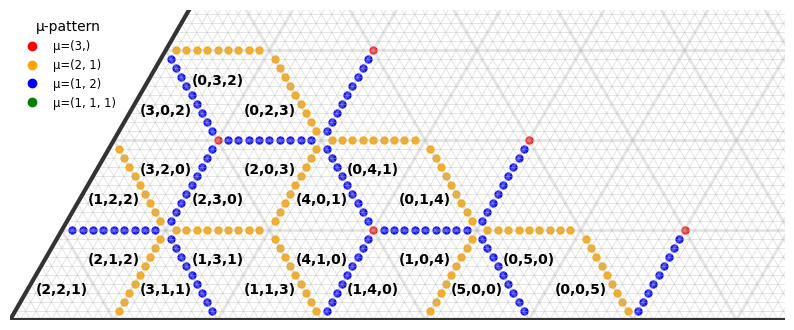

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
sl3_mu_indexed_plot.py

r = 3. For fixed (e, w) we:

- Enumerate 3-part partitions λ = (λ1 ≥ λ2 ≥ λ3 ≥ 0) up to a safe bound Lmax(e,w).
- Keep those with given e-weight w (via abacus).
- For each λ:
    * Compute μ = composition of 3 from residues of β-numbers.
    * Compute Λ = (λ^(1),...,λ^(j)) from vertical gaps q_j - j on each runner.
    * Compute dominant weight (ω1,ω2) of λ+ρ.
- Group weights by (μ, Λ).

We then draw the standard sl3 alcove (equilateral model):

- A2 mesh; lines at multiples of e bold.
- Dominant chamber wedge.
- Points (little balls) coloured by μ-pattern.

Special behaviour (as requested):

1. μ=(1,1,1) points:
   - Do NOT draw the green dots (i.e. hide W_{3,e,0}(1,1,1) points),
   - BUT still draw labels for these simplices.

2. Labels:
   - For μ=(1,1,1): show Λ as a weak composition (λ1,λ2,λ3),
     where each λi is the first part of λ^(i) or 0 if λ^(i) is empty.
   - For other μ: show compact multipartition label.
   - label_mu:
       * None      -> label all simplices (label in μ-colour).
       * (3,), (2,1), (1,2), (1,1,1)
                    -> label ONLY that μ, in bold black.

Minimal changes; rest of geometry & indexing unchanged.
"""

import math
from collections import defaultdict
from typing import Dict, List, Tuple, Set, Optional

import matplotlib.pyplot as plt
from matplotlib.path import Path

# -----------------------------
# Global style & palette
# -----------------------------

SQRT3 = math.sqrt(3.0)
SQRT3_2 = SQRT3 / 2.0

# μ-colours:
MU_COLOURS: Dict[Tuple[int, ...], str] = {
    (3,): "red",
    (2, 1): "orange",
    (1, 2): "blue",
    (1, 1, 1): "green",
}
MU_ORDER = [(3,), (2, 1), (1, 2), (1, 1, 1)]


# -----------------------------
# 1. r=3 partitions & abacus
# -----------------------------

def enumerate_partitions(Lmax: int):
    """
    Enumerate 3-part partitions λ = (λ1 ≥ λ2 ≥ λ3 ≥ 0) with 0 ≤ λ1 ≤ Lmax.
    """
    for l1 in range(Lmax + 1):
        for l2 in range(l1 + 1):
            for l3 in range(l2 + 1):
                yield (l1, l2, l3)


def beta_numbers(lam: Tuple[int, int, int]) -> List[int]:
    """
    r=3 β-numbers:
        β1 = λ1 + 2,
        β2 = λ2 + 1,
        β3 = λ3 + 0.
    """
    l1, l2, l3 = lam
    return [l1 + 2, l2 + 1, l3]


def abacus_from_lam(lam: Tuple[int, int, int], e: int) -> Dict[int, List[int]]:
    """
    Build e-runner abacus from λ:
      β = r + e q  -> bead at (runner r, level q).
    Returns dict r -> sorted list of q.
    """
    per: Dict[int, List[int]] = defaultdict(list)
    for b in beta_numbers(lam):
        r = b % e
        q = b // e
        per[r].append(q)
    for r in per:
        per[r].sort()
    return per


def lam_from_betas(betas: List[int]) -> Tuple[int, int, int]:
    """
    Invert β ↦ λ for r=3.
    """
    bs = sorted(betas, reverse=True)
    assert len(bs) == 3
    l1 = bs[0] - 2
    l2 = bs[1] - 1
    l3 = bs[2] - 0
    assert l1 >= l2 >= l3 >= 0
    return (l1, l2, l3)


def lam_from_abacus(per: Dict[int, List[int]], e: int) -> Tuple[int, int, int]:
    """
    Collect β = r + e q from abacus and convert to λ.
    """
    betas: List[int] = []
    for r, qs in per.items():
        for q in qs:
            betas.append(r + e * q)
    return lam_from_betas(betas)


def e_weight(lam: Tuple[int, int, int], e: int) -> int:
    """
    e-weight via abacus:
      For each runner:
         q_0 ≤ ... ≤ q_{μ-1},
         contrib = sum_j (q_j - j),
      sum over runners.
    """
    per = abacus_from_lam(lam, e)
    w = 0
    for qs in per.values():
        for j, q in enumerate(sorted(qs)):
            w += (q - j)
    return w


def mu_composition(lam: Tuple[int, int, int], e: int) -> Tuple[int, ...]:
    """
    μ-composition from residues of β:
      - Count beads on each runner,
      - Sort runners,
      - Return their counts as a composition of 3.
    """
    counts: Dict[int, int] = defaultdict(int)
    for b in beta_numbers(lam):
        counts[b % e] += 1
    runners = sorted(counts.keys())
    return tuple(counts[r] for r in runners)


def multipartition_index(lam: Tuple[int, int, int], e: int):
    """
    From abacus of λ, extract (μ, Λ):

      For each runner r used:
        μ_i = #beads,
        q_0 ≤ ... ≤ q_{μ_i-1},
        d_k = q_k - k ≥ 0,
        positive d_k in decreasing order form λ^(i).

    Returns
    -------
    μ : tuple of ints           (composition of 3)
    Λ : tuple of partitions     (each a tuple of ints in decreasing order)
    """
    per = abacus_from_lam(lam, e)
    runners = sorted(per.keys())
    mu = tuple(len(per[r]) for r in runners)

    multipart: List[Tuple[int, ...]] = []
    for r in runners:
        qs = sorted(per[r])
        diffs = [q - j for j, q in enumerate(qs)]
        parts = sorted((d for d in diffs if d > 0), reverse=True)
        multipart.append(tuple(parts))

    return mu, tuple(multipart)


def omega_coords_lambda_plus_rho(lam: Tuple[int, int, int]) -> Tuple[int, int]:
    """
    Dominant weight (λ+ρ) in (ω1,ω2):
        ω1 = λ1 - λ2 + 1,
        ω2 = λ2 - λ3 + 1.
    """
    l1, l2, l3 = lam
    return (l1 - l2 + 1, l2 - l3 + 1)


# -----------------------------
# 2. Safe Lmax(e,w)
# -----------------------------

def safe_Lmax(e: int, w: int) -> int:
    """
    Safe bound for λ1 with r=3, given e-weight w.

    Argument:
      q_j - j ≥ 0, sum(q_j - j) = w => q_j ≤ j + w.
      max q_j ≤ 2 + w.
      β_max < e(w+3), λ1 = β_max - 2 < e(w+3).

    We just take Lmax = e*(w+3).
    """
    return e * (w + 3)


# -----------------------------
# 3. Build (μ,Λ) -> weights
# -----------------------------

def build_mu_Lambda_buckets(e: int, w: int):
    """
    Enumerate λ with e-weight(λ)=w up to Lmax(e,w),
    and group dominant weights by (μ, Λ).

    Returns
    -------
    buckets : dict
        key:   (μ, Λ)
        value: set of (ω1,ω2)
    """
    Lmax = safe_Lmax(e, w)
    buckets: Dict[
        Tuple[Tuple[int, ...], Tuple[Tuple[int, ...], ...]],
        Set[Tuple[int, int]],
    ] = defaultdict(set)

    for lam in enumerate_partitions(Lmax):
        if e_weight(lam, e) != w:
            continue
        mu, multipart = multipartition_index(lam, e)
        omega = omega_coords_lambda_plus_rho(lam)
        buckets[(mu, multipart)].add(omega)

    return buckets


# -----------------------------
# 4. Equilateral sl3 geometry
# -----------------------------

def to_equilateral(points_fw: List[Tuple[int, int]]):
    """
    (ω1,ω2) -> (x,y):
      x = ω1 + 0.5 ω2,
      y = (√3/2) ω2.
    """
    X, Y = [], []
    for w1, w2 in points_fw:
        X.append(w1 + 0.5 * w2)
        Y.append(SQRT3_2 * w2)
    return X, Y


def extents_from_buckets(buckets) -> Tuple[float, float, float, float]:
    pts = [p for pts in buckets.values() for p in pts]
    if not pts:
        return (0.0, 1.0, 0.0, 1.0)
    X, Y = to_equilateral(pts)
    xmin, xmax = min(X), max(X)
    ymin, ymax = min(Y), max(Y)
    mx = max(1.5, 0.15 * (xmax - xmin + 1.0))
    my = max(1.5, 0.15 * (ymax - ymin + 1.0))
    return max(0.0, xmin - mx), xmax + mx, max(0.0, ymin - my), ymax + my


def draw_grid_equilateral(ax, xmin, xmax, ymin, ymax, e: int,
                          alpha: float = 0.35,
                          lw: float = 0.7,
                          lw_bold: float = 2.0):
    """
    A2 mesh with lines:
      ω2 = const, ω1 = const, ω1+ω2 = const;
    multiples of e are bold.
    """
    # ω2 = n
    n2_max = int((2.0 / SQRT3) * (ymax + 1.0)) + 1
    for n in range(0, n2_max + 1):
        y = SQRT3_2 * n
        if y < ymin - 1 or y > ymax + 1:
            continue
        x0 = max(xmin, y / SQRT3)
        bold = (n % e == 0 and n != 0)
        ax.plot(
            [x0, xmax],
            [y, y],
            color="0.7",
            alpha=alpha,
            linewidth=(lw_bold if bold else lw),
        )

    # ω1 = n
    n1_min = max(0, int(xmin) - 2)
    n1_max = int(xmax) + 2
    t_cap = int((2.0 / SQRT3) * (ymax + 1.0)) + 1
    for n in range(n1_min, n1_max + 1):
        x0, y0 = (n, 0.0)
        x1, y1 = (n + 0.5 * t_cap, SQRT3_2 * t_cap)
        bold = (n % e == 0 and n != 0)
        ax.plot(
            [x0, x1],
            [y0, y1],
            color="0.7",
            alpha=alpha,
            linewidth=(lw_bold if bold else lw),
        )

    # ω1 + ω2 = m
    m_min = max(0, int(xmin)) - 2
    m_max = int(xmax + (2.0 / SQRT3) * (ymax + 1.0)) + 2
    for m in range(m_min, m_max + 1):
        x0, y0 = (m, 0.0)
        t_cap = min(max(0.0, (ymax + 1.0) * 2.0 / SQRT3), m)
        x1 = m - 0.5 * t_cap
        y1 = SQRT3_2 * t_cap
        bold = (m % e == 0 and m != 0)
        ax.plot(
            [x0, x1],
            [y0, y1],
            color="0.7",
            alpha=alpha,
            linewidth=(lw_bold if bold else lw),
        )


def wedge_clip_equilateral(xmin, xmax, ymin, ymax):
    """
    Dominant chamber wedge (as Path), if you decide to clip.
    """
    x0 = max(xmin, 0.0)
    x1 = min(xmax, ymax / SQRT3)
    verts = [
        (xmin, 0.0),
        (xmax, 0.0),
        (x1, SQRT3 * x1),
        (x0, SQRT3 * x0),
        (xmin, 0.0),
    ]
    codes = [Path.MOVETO] + [Path.LINETO] * 3 + [Path.CLOSEPOLY]
    return Path(verts, codes)


def draw_wedge_outline_equilateral(ax, xmin, xmax, ymin, ymax, lw: float = 3.0):
    """
    Draw boundary of dominant wedge: y=0 and y=√3 x.
    """
    ax.plot([xmin, xmax], [0.0, 0.0], color="0.2", linewidth=lw)
    x0 = max(xmin, 0.0)
    x1 = min(xmax, ymax / SQRT3)
    ax.plot([x0, x1], [SQRT3 * x0, SQRT3 * x1], color="0.2", linewidth=lw)


# -----------------------------
# 5. Labels
# -----------------------------

def multipartition_label(multipart: Tuple[Tuple[int, ...], ...]) -> str:
    """
    Default compact label for Λ = (λ^(1),...,λ^(j)):
      "(2,1)·(1)·∅"
    """
    pieces: List[str] = []
    for lam in multipart:
        if not lam:
            pieces.append("∅")
        else:
            pieces.append("(" + ",".join(str(x) for x in lam) + ")")
    return "·".join(pieces)


def multipartition_label_compact(
    mu: Tuple[int, ...],
    multipart: Tuple[Tuple[int, ...], ...],
) -> str:
    """
    For μ=(1,1,1):
      Λ = (λ^(1),λ^(2),λ^(3)), each of length ≤1.
      Label as weak composition (a,b,c) with a,b,c ≥ 0,
      where a is first part of λ^(1) or 0 if empty, etc.

    For other μ:
      fall back to multipartition_label.
    """
    if mu == (1, 1, 1) and len(multipart) == 3:
        def first_or_zero(part: Tuple[int, ...]) -> int:
            return part[0] if part else 0

        a = first_or_zero(multipart[0])
        b = first_or_zero(multipart[1])
        c = first_or_zero(multipart[2])
        return f"({a},{b},{c})"
    else:
        return multipartition_label(multipart)


# -----------------------------
# 6. Main plotting function
# -----------------------------

def plot_sl3_indexed_simplices(
    e: int,
    w: int,
    label_mu: Optional[Tuple[int, ...]] = None,
    label_fontsize: int = 7,
    max_labels: int = 999,
    out_prefix: Optional[str] = None,
):
    """
    Draw the sl3 alcove picture for (r,e,w)=(3,e,w).

    - All points coloured by μ, EXCEPT:
        μ=(1,1,1): we DO NOT draw those dots (green cloud suppressed).
    - Labels:
        If label_mu is None:
            * Label all simplices:
                μ≠(1,1,1): use multipartition_label (colour = μ-colour),
                μ=(1,1,1): use (λ1,λ2,λ3) with zeros.
        If label_mu is one of (3,), (2,1), (1,2), (1,1,1):
            * Only that μ is labelled, in bold BLACK,
              with same label shapes as above.
    """
    buckets = build_mu_Lambda_buckets(e, w)

    all_points = [p for pts in buckets.values() for p in pts]
    if not all_points:
        raise RuntimeError(f"No points for (e,w)=({e},{w}).")

    xmin, xmax, ymin, ymax = extents_from_buckets(buckets)

    fig, ax = plt.subplots(figsize=(10, 8))

    draw_grid_equilateral(ax, xmin, xmax, ymin, ymax, e)
    _ = wedge_clip_equilateral(xmin, xmax, ymin, ymax)  # ready if needed

    # Dot size schedule (mildly shrink with w)
    sz = int(round(32 - 14 * min(max(w, 0), 10) / 10.0))
    sz = max(18, min(32, sz))

    labels_drawn = 0

    for (mu, multipart), pts_fw in sorted(buckets.items()):
        if not pts_fw:
            continue

        color = MU_COLOURS.get(mu, "black")
        pts_sorted = sorted(pts_fw)
        X, Y = to_equilateral(pts_sorted)

        # 1) Draw points:
        #    Skip μ=(1,1,1) so those green dots disappear.
        if mu != (1, 1, 1):
            ax.scatter(X, Y, s=sz, marker="o", color=color, alpha=0.9)

        # 2) Decide if we label this simplex:

        if label_mu is None:
            # Label all simplices:
            do_label = True
            label_color = color
            bold = False
        else:
            # Label only simplices whose μ matches label_mu, in black & bold
            if mu == label_mu:
                do_label = True
                label_color = "black"
                bold = True
            else:
                do_label = False
                label_color = color
                bold = False

        if do_label and labels_drawn < max_labels:
            bx = sum(X) / len(X)
            by = sum(Y) / len(Y)
            label_text = multipartition_label_compact(mu, multipart)

            ax.text(
                bx,
                by,
                label_text,
                fontsize=label_fontsize,
                color=label_color,
                ha="center",
                va="center",
                fontweight="bold" if bold else "normal",
            )
            labels_drawn += 1

    # Wedge outline
    draw_wedge_outline_equilateral(ax, xmin, xmax, ymin, ymax, lw=3.0)

    # Cosmetics
    ax.set_aspect("equal", "box")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(max(0.0, ymin), ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # (r,e,w) label outside chamber, upper-left
    # fig.text(
    #     0.02,
    #     0.98,
    #     f"(r,e,w)=(3,{e},{w})",
    #     ha="left",
    #     va="top",
    #     fontsize=14,
    #     weight="bold",
    # )

    # μ-colour legend in upper-left (still includes μ=(1,1,1))
    from matplotlib.lines import Line2D
    legend_elements: List[Line2D] = []
    for mu_key in MU_ORDER:
        if any(key_mu == mu_key for (key_mu, _Λ) in buckets.keys()):
            legend_elements.append(
                Line2D(
                    [0],
                    [0],
                    marker="o",
                    linestyle="",
                    markersize=6,
                    color=MU_COLOURS[mu_key],
                    label=f"μ={mu_key}",
                )
            )
    if legend_elements:
        ax.legend(
            handles=legend_elements,
            title="μ-pattern",
            loc="upper left",
            frameon=False,
            fontsize="small",
        )

    # Save if requested
    if out_prefix:
        fig.savefig(f"{out_prefix}.png", dpi=240, bbox_inches="tight")
        # fig.savefig(f"{out_prefix}.pdf", dpi=240, bbox_inches="tight")

    return fig, ax, buckets


# -----------------------------
# 7. Example direct run
# -----------------------------

if __name__ == "__main__":
    # Example: choose a relatively small (e,w) to test visually
    e, w = 10, 5

    # Label only μ=(1,1,1) in bold black; green dots suppressed, labels as (a,b,c)
    fig, ax, buckets = plot_sl3_indexed_simplices(
        e=e,
        w=w,
        label_mu=(1, 1, 1),
        label_fontsize=10,
        max_labels=999,
        out_prefix=f"sl3_e{e}_w{w}_mu111_labels"
    )

    print(f"(r,e,w)=(3,{e},{w}) has {len(buckets)} (μ,Λ)-simplices.")
    for (mu, Λ), pts in sorted(buckets.items()):
        print(f"  μ={mu}, Λ={multipartition_label_compact(mu, Λ):10s} -> {len(pts)} points")
